In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import os
import re
import pandas as pd

root = r"C:\Users\cronk\.vscode\Sticky_Dumbbell_MS_Project\RDP_ExptDHR2"   # parent of the five sub‑folders
folders = sorted(
    os.path.join(root, d) for d in os.listdir(root)
    if os.path.isdir(os.path.join(root, d))
)

df_by_folder = {}        # will hold one DataFrame per folder

# regex to grab only the numeric part (e.g. 10, 15) from the DP pattern
dp_re = re.compile(r"_(\d+)DP_")

for folder in folders:
    rows   = []          # list of one‑row DataFrames
    names  = []          # corresponding file names for the index
    for fname in sorted(os.listdir(folder)):
        # only read the "_parameters.csv" files
        if not fname.lower().endswith("_goodness.csv"):
            continue
        path = os.path.join(folder, fname)
        df = pd.read_csv(path)          # each file is assumed to contain exactly one row
        if len(df) != 1:
            raise ValueError(f"{path!r} has {len(df)} rows; expected 1")
        # --- extract DP and add as column ---
        m = dp_re.search(fname)
        if m:
            # DP comes from the filename; convert from string to integer so
            # later sorting/plotting works numerically instead of
            # lexicographically ("8" would otherwise come after "22").
            df['DP'] = int(m.group(1))
        else:
            df['DP'] = pd.NA
        # --- option A: add filename as a column ---
        df['set'] = os.path.splitext(fname)[0]
        rows.append(df)
        # --- option B: use names list for a MultiIndex below ---

        names.append(os.path.splitext(fname)[0])

    if not rows:
        continue

    # vertical concatenation: 5 files → 5 rows
    combined = pd.concat(rows, ignore_index=True)

    # if you prefer the filename as the row index instead of a column:
    # combined = pd.concat(rows, keys=names, names=['set'])

    df_by_folder[os.path.basename(folder)] = combined

print(df_by_folder['RDP_ExptDHR2_303_data'])
# inspect one folder

      R2_Gp    R2_Gpp  R2_total  R2_log_Gp  R2_log_Gpp  R2_log_total  \
0  0.980093  0.856523  0.973788   0.995693    0.944636      0.988858   
1  0.985410  0.878637  0.980353   0.994948    0.946582      0.988794   
2  0.983161  0.832164  0.976147   0.994553    0.933058      0.986881   
3  0.981432  0.867832  0.975637   0.994620    0.952391      0.988935   
4  0.983077  0.871816  0.977111   0.994963    0.948616      0.988849   
5  0.983486  0.882159  0.978230   0.995088    0.949414      0.989099   
6  0.982783  0.865019  0.976577   0.995020    0.950066      0.989056   
7  0.983209  0.864959  0.977287   0.994953    0.947950      0.988722   
8  0.981508  0.846693  0.975001   0.995261    0.957902      0.990272   

      RMSE_Gp    RMSE_Gpp  Reduced_chi2         AIC  DP  \
0  630.441955  491.016245      0.025351  312.171545  12   
1  540.338381  427.386347      0.020190  404.068237  16   
2  587.829740  495.652878      0.023269  511.871553  20   
3  595.300496  460.969276      0.022376  61

In [6]:
df_by_folder['RDP_ExptDHR2_303_data']

,R2_Gp,R2_Gpp,R2_total,R2_log_Gp,R2_log_Gpp,R2_log_total,RMSE_Gp,RMSE_Gpp,Reduced_chi2,AIC,DP,set
0,0.980093,0.856523,0.973788,0.995693,0.944636,0.988858,630.441955,491.016245,0.025351,312.171545,12,fit_ExptDHR2_303.bbx_12DP_goodness
1,0.985410,0.878637,0.980353,0.994948,0.946582,0.988794,540.338381,427.386347,0.020190,404.068237,16,fit_ExptDHR2_303.bbx_16DP_goodness
2,0.983161,0.832164,0.976147,0.994553,0.933058,0.986881,587.829740,495.652878,0.023269,511.871553,20,fit_ExptDHR2_303.bbx_20DP_goodness
3,0.981432,0.867832,0.975637,0.994620,0.952391,0.988935,595.300496,460.969276,0.022376,610.627882,24,fit_ExptDHR2_303.bbx_24DP_goodness
4,0.983077,0.871816,0.977111,0.994963,0.948616,0.988849,568.377432,453.846184,0.020841,707.196503,28,fit_ExptDHR2_303.bbx_28DP_goodness
5,0.983486,0.882159,0.978230,0.995088,0.949414,0.989099,559.273615,434.319281,0.019453,803.651366,32,fit_ExptDHR2_303.bbx_32DP_goodness
6,0.982783,0.865019,0.976577,0.995020,0.950066,0.989056,583.250492,470.767986,0.021734,911.294755,36,fit_ExptDHR2_303.bbx_36DP_goodness
7,0.983209,0.864959,0.977287,0.994953,0.947950,0.988722,575.823808,463.156209,0.021262,959.321329,38,fit_ExptDHR2_303.bbx_38DP_goodness
8,0.981508,0.846693,0.975001,0.995261,0.957902,0.990272,638.821997,517.490492,0.031350,211.690214,8,fit_ExptDHR2_303.bbx_8DP_goodness


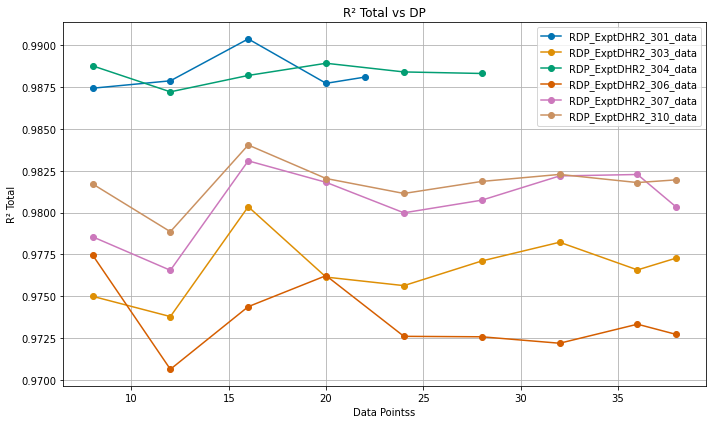

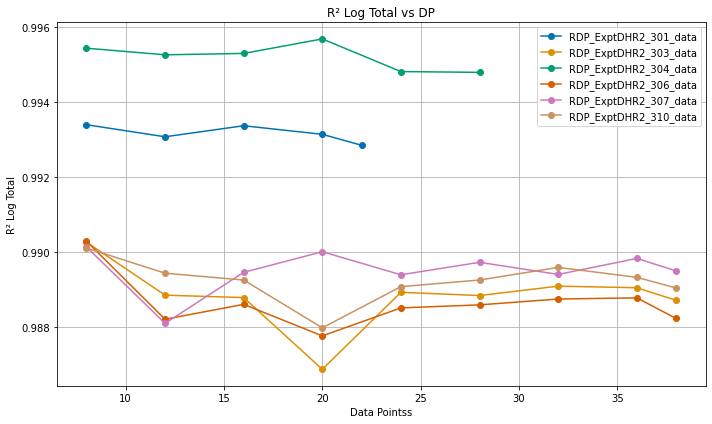

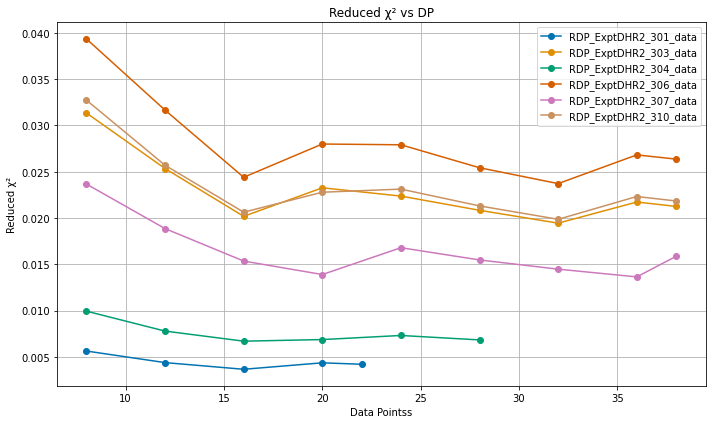

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# choose a colourblind-friendly palette
sns.set_palette("colorblind")

def plot_all_folders_vs_dp(df_by_folder, metric, title, ylabel):
    """Plot a metric vs DP for all folders on the same graph."""
    plt.figure(figsize=(10, 6))
    
    for folder_name, df in df_by_folder.items():
        # Drop rows with NA in DP column
        df_clean = df.dropna(subset=['DP'])
        if len(df_clean) == 0:
            continue
        # Sort by DP to ensure lines connect properly
        df_sorted = df_clean.sort_values('DP')
        plt.plot(df_sorted['DP'], 
                 df_sorted[metric], 
                 marker='o', 
                 linestyle='-',
                 label=folder_name)
    
    plt.xlabel('Data Pointss')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

# Three graphs comparing all folders
plot_all_folders_vs_dp(df_by_folder, 'R2_total', 'R² Total vs DP', 'R² Total')
plt.savefig('all_folders_R2_total_vs_DP.png')
plt.show()

plot_all_folders_vs_dp(df_by_folder, 'R2_log_total', 'R² Log Total vs DP', 'R² Log Total')
plt.savefig('all_folders_R2_log_total_vs_DP.png')
plt.show()

plot_all_folders_vs_dp(df_by_folder, 'Reduced_chi2', 'Reduced χ² vs DP', 'Reduced χ²')
plt.savefig('all_folders_Reduced_chi2_vs_DP.png')
plt.show()